In [ ]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.resampled_data_loader import get_resampled_quotes

instruments = ['USDSGD', 'EURUSD', 'AUDUSD', 'GBPUSD', 'USDJPY', 'USDHKD']
ccys = ['USD', 'EUR', 'AUD', 'GBP', 'JPY', 'HKD']

start_date = dt.datetime(2025, 1, 1)
end_date = dt.datetime(2025, 12, 31)
freq = pd.Timedelta(minutes=15)

prices = get_resampled_quotes(instruments, start_date, end_date, freq)

In [79]:
def regression_stats(x, y):
    sample = pd.concat({"x": x, "y": y}, axis=1).dropna()
    if len(sample) < 3 or sample["x"].var() == 0 or sample["y"].var() == 0:
        return np.nan, np.nan, len(sample)

    beta = sample["y"].cov(sample["x"]) / sample["x"].var()
    corr = sample["x"].corr(sample["y"])
    return beta, corr, len(sample)

In [ ]:
import importlib
import strategy.sgd_neer_strategy as sn

importlib.reload(sn)
from strategy.sgd_neer_strategy import SGDNEERStrategy

strategy = SGDNEERStrategy(instruments, prices,
                        {
                            "rolling_window" : pd.Timedelta(minutes=15),
                            "zscore_window" : pd.Timedelta(minutes=1200),
                            "zscore_entry_threshold" : 2.5,
                            "zscore_exit_threshold" : 0.0,
                            "spread_entry_multiplier" : 3.0
                        })


In [132]:
signals = strategy.generate_signals()


In [61]:
ccy_signals = strategy._currency_signals(strategy.build_rets_vs_sgd())
pd.DataFrame(ccy_signals)

,USD,EUR,JPY,AUD,GBP,HKD
timestamp,,,,,,
2025-01-01 18:00:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:15:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:30:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:45:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 19:00:00-05:00,0.0,1.0,-1.0,0.0,1.0,0.0
...,...,...,...,...,...,...
2025-12-31 15:45:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31 16:00:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31 16:15:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0


In [133]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(instruments, prices, signals)

report = PerformanceReport(instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
USDSGD,-13.186761,-0.250374,12.571429,-6.564795,-0.14976,-0.001434,-0.000003,0 days 00:17:39.642857,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
EURUSD,-2.189982,1.506753,6.28022,-0.067661,-0.005547,-0.000025,0.000017,0 days 00:18:08.319327,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
AUDUSD,-5.59598,2.297335,5.543956,-0.186606,-0.009866,-0.000092,0.000033,0 days 00:18:19.617590,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
GBPUSD,-5.46846,1.269585,5.392857,-0.117465,-0.005856,-0.000059,0.000012,0 days 00:15:24.950495,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
USDJPY,-3.103898,0.854142,7.832418,-0.105676,-0.008548,-0.000035,0.000009,0 days 00:15:38.310810,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
USDHKD,-12.825672,1.252154,6.085165,-0.078512,-0.001451,-0.000035,0.000001,0 days 00:20:42.820292,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00


<Axes: title={'center': 'GBPUSD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

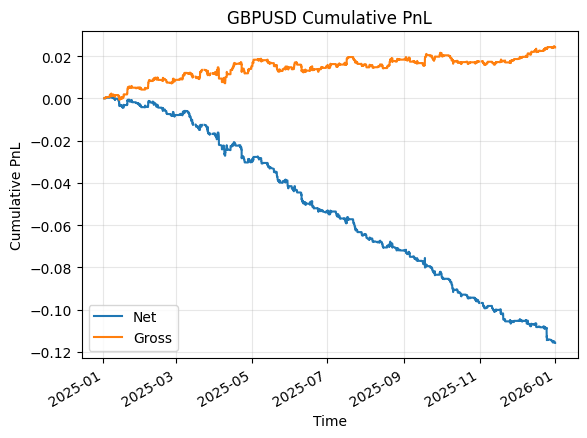

In [134]:
report.plot_cumulative_pnl('GBPUSD')

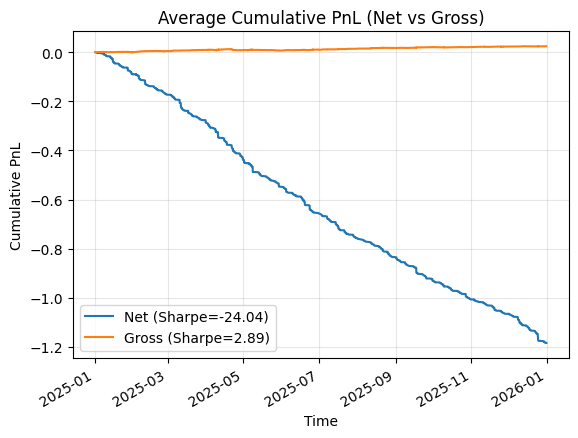

In [137]:
import numpy as np

freq_mult = pd.Timedelta(days=1) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [77]:
rets_vs_sgd = strategy.build_rets_vs_sgd()

In [ ]:
rolling_windows_mins = [15, 30, 60, 120]
fwd_periods_mins = [15, 30, 60]

zscore_window_mins = 120

bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = [x // bar_minutes for x in rolling_windows_mins]
fwd_periods = [x // bar_minutes for x in fwd_periods_mins]
zscore_window = zscore_window_mins // bar_minutes

zscore_bins = [
    (0, 0.5),
    (0.5, 1),
    (1, 2),
    (2, np.inf),
]

results = []

for rolling_window_mins, rolling_window in zip(rolling_windows_mins, rolling_windows):
    for fwd_period_mins, fwd_period in zip(fwd_periods_mins, fwd_periods):
        for ccy in ccys + ["index"]:
            if ccy == "index":
                past_ret = rets_vs_sgd["index"].rolling(rolling_window).sum()
            else:
                past_ret = (
                    rets_vs_sgd[ccy] - rets_vs_sgd["index"]
                ).rolling(rolling_window).sum()

            past_z = (
                (past_ret - past_ret.rolling(zscore_window).mean())
                / past_ret.rolling(zscore_window).std()
            )

            future_ccy_ret = (
                rets_vs_sgd[ccy]
                .rolling(fwd_period)
                .sum()
                .shift(-fwd_period)
            )

            abs_z = past_z.abs()

            for lower, upper in zscore_bins:
                if np.isinf(upper):
                    bucket_mask = abs_z > lower
                    z_bucket = f">{lower}"
                else:
                    bucket_mask = (abs_z >= lower) & (abs_z < upper)
                    z_bucket = f"{lower}-{upper}"

                beta, corr, n_obs = regression_stats(
                    past_z[bucket_mask],
                    future_ccy_ret[bucket_mask],
                )

                results.append({
                    "ccy": ccy,
                    "rolling_window_mins": rolling_window_mins,
                    "fwd_period_mins": fwd_period_mins,
                    "zscore_window_mins": zscore_window_mins,
                    "z_bucket": z_bucket,
                    "beta": beta,
                    "corr": corr,
                    "n_obs": n_obs,
                })

zscore_bucket_results = pd.DataFrame(results)

zscore_bucket_results.sort_values(
    ["rolling_window_mins", "fwd_period_mins", "ccy", "z_bucket"]
)


,ccy,rolling_window_mins,fwd_period_mins,zscore_window_mins,z_bucket,beta,corr,n_obs
8,AUD,15,15,120,0-0.5,-1.320764e-05,-0.007810,9715
9,AUD,15,15,120,0.5-1,1.348920e-05,0.021846,7285
10,AUD,15,15,120,1-2,-2.307882e-06,-0.006397,6976
11,AUD,15,15,120,>2,-9.211612e-07,-0.002953,647
4,EUR,15,15,120,0-0.5,-8.568399e-06,-0.007327,9611
...,...,...,...,...,...,...,...,...
311,USD,120,60,120,>2,1.199804e-06,0.003590,895
332,index,120,60,120,0-0.5,-1.101756e-05,-0.010205,6292
333,index,120,60,120,0.5-1,-1.005543e-05,-0.024727,6798
334,index,120,60,120,1-2,-2.070822e-05,-0.088374,10619


In [75]:
zscore_bucket_results.pivot_table(
    index=["rolling_window_mins", "fwd_period_mins", "ccy"],
    columns="z_bucket",
    values="corr",
).to_clipboard()


In [78]:
rets_vs_sgd.columns.to_list()

['index', 'USD', 'EUR', 'JPY', 'AUD', 'GBP', 'HKD']

<Axes: xlabel='timestamp'>

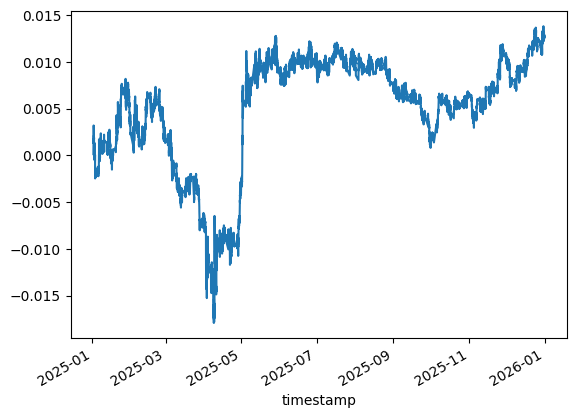

In [ ]:
rets['index'].cumsum().plot()

<Axes: xlabel='timestamp'>

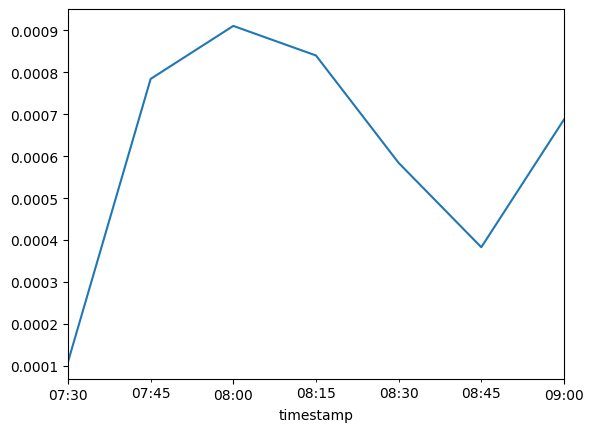

In [13]:
rets.loc['2025-07-03 07:30' : '2025-07-03 09:00']['index'].cumsum().plot()

In [91]:
rolling_windows_mins = 15
fwd_periods_mins = 15
zscore_window_mins = 120
bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = rolling_windows_mins // bar_minutes
fwd_periods = fwd_periods_mins // bar_minutes
zscore_window = zscore_window_mins // bar_minutes

results = rets_vs_sgd.copy()

for ccy in ccys + ["index"]:

    past_ret = rets_vs_sgd[ccy].rolling(rolling_window).sum()
    past_relative_ret = (rets_vs_sgd[ccy] - rets_vs_sgd["index"]).rolling(rolling_window).sum()

    past_z = (
        (past_ret - past_ret.rolling(zscore_window).mean())
        / past_ret.rolling(zscore_window).std()
    )

    past_relative_z = (
        (past_relative_ret - past_relative_ret.rolling(zscore_window).mean())
        / past_relative_ret.rolling(zscore_window).std()
    )

    future_ccy_ret = (
        rets_vs_sgd[ccy]
        .rolling(fwd_period)
        .sum()
        .shift(-fwd_period)
    )

    results[ccy + "_past_ret"] = past_ret
    results[ccy + "_past_z"] = past_z
    results[ccy + "_past_relative_ret"] = past_relative_ret
    results[ccy + "_past_relative_z"] = past_relative_z

In [100]:
zs_mask = results["index_past_z"].abs() > 2.0
results[zs_mask].filter(like="_z").to_clipboard()

In [98]:
results.filter(like="past_z").to_clipboard()